# QoI convergence across spatial levels

This notebook performs the first convergence study for the KL diffusion problem. For every random sample, **the same Gaussian coefficient vector** \(\xi\) and therefore the same physical conductivity field \(\kappa(x,y;\xi)\) are used on every spatial level.

We record

$$
Q_0, Q_1, \ldots, Q_L,
$$

and the coupled level corrections

$$
Y_0=Q_0, \qquad Y_\ell=Q_\ell-Q_{\ell-1} \quad (\ell\geq1).
$$

As the spatial discretization converges, $Q_\ell$ should stabilize while the magnitude and variance of $Y_\ell$ should generally decrease. This notebook does **not** yet test V-cycle counts or timing; those can be added later without changing the data layout used here.

## 1. Imports and project paths

In [38]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


def find_project_root(start: Path) -> Path:
    """Find the ng26 project root from the notebook working directory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "examples").is_dir():
            return candidate

    raise RuntimeError("Could not locate the ng26 project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from KL_expansion import cartesian_grid_2d
from examples.KLMC.multilevel.multilevel_test import (
    MCLevelFactory,
    make_coefficient_from_xi,
)
from examples.KLMC.utils.analytical_eigenfunctions import (
    get_1d_eigenpairs,
    leading_2d_eigenpairs,
    make_2d_kl_evaluator,
)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/neal/Documents/Coursework/Notes/ng26


## 2. Experiment parameters

Start with a moderate number of samples so the notebook runs quickly. Increase `NUMBER_OF_SAMPLES` after verifying the workflow.

In [39]:
SEED = 7
NUMBER_OF_SAMPLES = 500
NUMBER_OF_LEVELS = 7

CORRELATION_LENGTH = 0.2
NUMBER_OF_MODES = 100
MEAN_LOG_CONDUCTIVITY = 0.0
STANDARD_DEVIATION = 1.0
KL_GRID_SIZE = 32

COARSE_MAXH = 0.2
FINITE_ELEMENT_ORDER = 1
RELATIVE_SOLVER_TOLERANCE = 1.0e-6
MAXIMUM_VCYCLES = 1_000

if NUMBER_OF_SAMPLES < 2:
    raise ValueError("At least two samples are required to estimate variances.")

if NUMBER_OF_LEVELS < 2:
    raise ValueError("At least two levels are required to form a difference.")

## 3. Construct the analytical KL expansion

The KL expansion returns the Gaussian **log-conductivity**. `make_coefficient_from_xi` exponentiates it and creates the positive `VoxelCoefficient` used by every spatial level.

In [40]:
X, Y, _ = cartesian_grid_2d(
    KL_GRID_SIZE,
    KL_GRID_SIZE,
)

(
    frequencies_1d,
    normalizations_1d,
    eigenvalues_1d,
    _,
) = get_1d_eigenpairs(
    num_modes=NUMBER_OF_MODES,
    correlation_length=CORRELATION_LENGTH,
)

(
    eigenvalues_2d,
    mode_indices_2d,
    evaluate_eigenfunctions_2d,
) = leading_2d_eigenpairs(
    eigenvalues_1d=eigenvalues_1d,
    frequencies_1d=frequencies_1d,
    normalizations_1d=normalizations_1d,
    correlation_length=CORRELATION_LENGTH,
    num_modes_2d=NUMBER_OF_MODES,
    method="heap",
)

evaluate_log_conductivity = make_2d_kl_evaluator(
    eigenvalues_2d=eigenvalues_2d,
    eigenfunction_evaluator=evaluate_eigenfunctions_2d,
    mean_log_conductivity=MEAN_LOG_CONDUCTIVITY,
    variance=STANDARD_DEVIATION**2,
)

coefficient_from_xi = make_coefficient_from_xi(
    X=X,
    Y=Y,
    evaluate_log_conductivity=evaluate_log_conductivity,
)

print(f"Constructed {len(eigenvalues_2d)} two-dimensional KL modes.")

Constructed 100 two-dimensional KL modes.


## 4. Build one solver object for each spatial level

The level-$\ell$ object owns the truncated hierarchy $0,\ldots,\ell$ required by its V-cycle. The conductivity is represented in an elementwise-constant `L2(order=0)` space, as configured in `MCLevel.build`.

In [41]:
mc_level_factory = MCLevelFactory(
    coarse_maxh=COARSE_MAXH,
    relative_solver_tolerance=RELATIVE_SOLVER_TOLERANCE,
    maximum_vcycles=MAXIMUM_VCYCLES,
    pre_sweeps=2,
    post_sweeps=2,
    coarse_direct=True,
    coarse_sweeps=20,
    dirichlet="left|right",
    dirichlet_value={
        "left": 1.0,
        "right": 0.0,
    },
    order=FINITE_ELEMENT_ORDER,
)

single_levels = tuple(
    mc_level_factory(level_index)
    for level_index in range(NUMBER_OF_LEVELS)
)

print(f"{'level':>5} {'finest ndof':>12} {'hierarchy levels':>17}")
print("-" * 38)
for level in single_levels:
    print(
        f"{level.level_index:>5} "
        f"{level.hierarchy.finest.fes.ndof:>12} "
        f"{level.hierarchy.nlevels:>17}"
    )

level  finest ndof  hierarchy levels
--------------------------------------
    0           37                 1
    1          125                 2
    2          457                 3
    3         1745                 4
    4         6817                 5
    5        26945                 6
    6       107137                 7


## 5. Run coupled single-level samples

Each row uses one shared $\xi^{(n)}$ on every level. This coupling is essential: subtracting QoIs generated from independent random fields would measure random-input differences instead of spatial-discretization differences.

In [42]:
rng = np.random.default_rng(SEED)
xi_samples = rng.standard_normal(
    (NUMBER_OF_SAMPLES, NUMBER_OF_MODES)
)
qois = np.empty(
    (NUMBER_OF_SAMPLES, NUMBER_OF_LEVELS)
)

started = time.perf_counter()
progress_interval = max(1, NUMBER_OF_SAMPLES // 10)

for sample_index, xi in enumerate(xi_samples):
    # Construct one physical random field and reuse that exact object
    # for Q_0, Q_1, ..., Q_L.
    kappa = coefficient_from_xi(xi)

    for level_index, level in enumerate(single_levels):
        qois[sample_index, level_index] = level.solve_qoi(kappa)

    completed = sample_index + 1
    if completed % progress_interval == 0 or completed == NUMBER_OF_SAMPLES:
        print(f"completed {completed:>4}/{NUMBER_OF_SAMPLES} samples")

elapsed_seconds = time.perf_counter() - started

if not np.all(np.isfinite(qois)):
    raise RuntimeError("At least one QoI is nonfinite.")

print(f"Elapsed time: {elapsed_seconds:.2f} seconds")
print(f"Stored QoI array shape: {qois.shape}")

completed   50/500 samples
completed  100/500 samples
completed  150/500 samples
completed  200/500 samples
completed  250/500 samples
completed  300/500 samples
completed  350/500 samples
completed  400/500 samples
completed  450/500 samples
completed  500/500 samples
Elapsed time: 132.94 seconds
Stored QoI array shape: (500, 7)


## 6. Form the level corrections and summary statistics

In [43]:
corrections = np.empty_like(qois)
corrections[:, 0] = qois[:, 0]
corrections[:, 1:] = np.diff(qois, axis=1)

mean_qoi = np.mean(qois, axis=0)
variance_qoi = np.var(qois, axis=0, ddof=1)
standard_error_qoi = np.sqrt(variance_qoi / NUMBER_OF_SAMPLES)

mean_correction = np.mean(corrections, axis=0)
mean_absolute_correction = np.mean(np.abs(corrections), axis=0)
variance_correction = np.var(corrections, axis=0, ddof=1)

print(
    f"{'level':>5} {'mean(Q_l)':>14} {'Var(Q_l)':>14} "
    f"{'mean(Y_l)':>14} {'mean|Y_l|':>14} {'Var(Y_l)':>14}"
)
print("-" * 84)

for level_index in range(NUMBER_OF_LEVELS):
    print(
        f"{level_index:>5} "
        f"{mean_qoi[level_index]:>14.6e} "
        f"{variance_qoi[level_index]:>14.6e} "
        f"{mean_correction[level_index]:>14.6e} "
        f"{mean_absolute_correction[level_index]:>14.6e} "
        f"{variance_correction[level_index]:>14.6e}"
    )

level      mean(Q_l)       Var(Q_l)      mean(Y_l)      mean|Y_l|       Var(Y_l)
------------------------------------------------------------------------------------
    0   1.095485e+00   1.622550e-01   1.095485e+00   1.095485e+00   1.622550e-01
    1   1.054411e+00   1.146280e-01  -4.107434e-02   2.007459e-01   6.791932e-02
    2   1.048147e+00   1.015234e-01  -6.263734e-03   7.668694e-02   1.015838e-02
    3   1.046436e+00   1.021676e-01  -1.711270e-03   1.443426e-02   3.598377e-04
    4   1.046789e+00   1.032227e-01   3.531158e-04   5.052105e-03   4.593500e-05
    5   1.047641e+00   1.039310e-01   8.518933e-04   2.781326e-03   1.360905e-05
    6   1.048172e+00   1.043208e-01   5.308467e-04   1.360815e-03   3.301268e-06


## 7. Visualize convergence with level

The first panel shows paired QoI trajectories. The second shows the distributions of the actual corrections $Q_\ell-Q_{\ell-1}$. The third shows the correction variance, which is the quantity used by MLMC sample allocation.

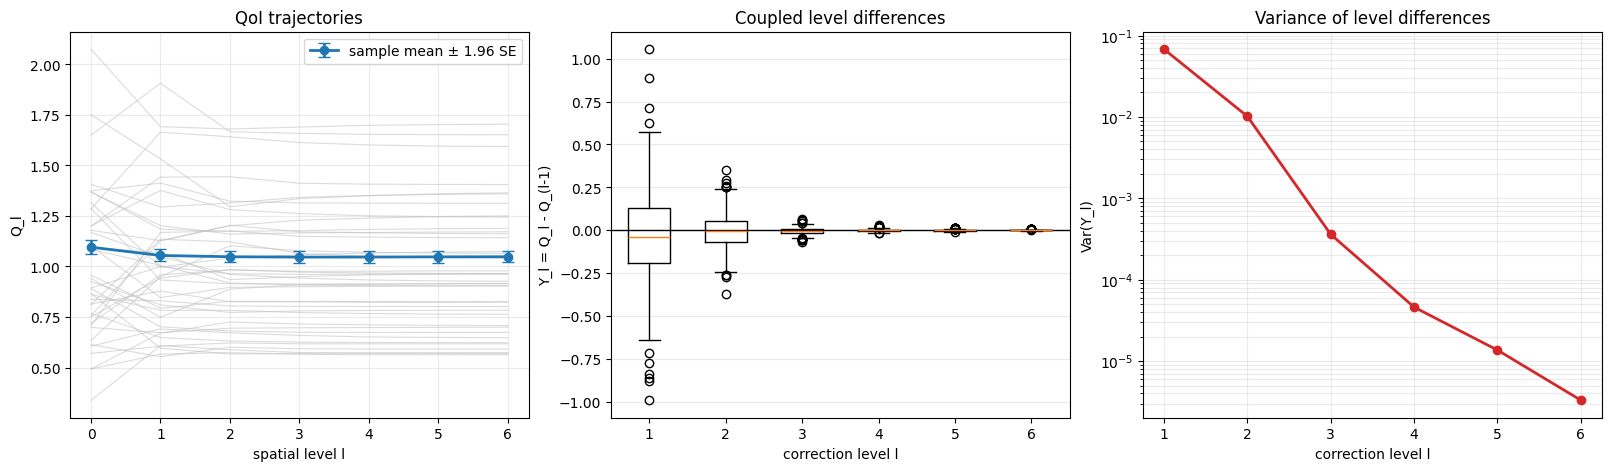

In [44]:
level_indices = np.arange(NUMBER_OF_LEVELS)
correction_level_indices = level_indices[1:]
number_of_trajectories = min(NUMBER_OF_SAMPLES, 40)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16.0, 4.6),
    constrained_layout=True,
)

for sample_qois in qois[:number_of_trajectories]:
    axes[0].plot(
        level_indices,
        sample_qois,
        color="0.75",
        linewidth=0.8,
        alpha=0.55,
    )

axes[0].errorbar(
    level_indices,
    mean_qoi,
    yerr=1.96 * standard_error_qoi,
    color="tab:blue",
    marker="o",
    linewidth=2.0,
    capsize=4,
    label="sample mean ± 1.96 SE",
)
axes[0].set_title("QoI trajectories")
axes[0].set_xlabel("spatial level l")
axes[0].set_ylabel("Q_l")
axes[0].set_xticks(level_indices)
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].boxplot(
    [corrections[:, level] for level in correction_level_indices],
    positions=correction_level_indices,
    widths=0.55,
    showfliers=True,
)
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].set_title("Coupled level differences")
axes[1].set_xlabel("correction level l")
axes[1].set_ylabel("Y_l = Q_l - Q_(l-1)")
axes[1].set_xticks(correction_level_indices)
axes[1].grid(axis="y", alpha=0.25)

axes[2].semilogy(
    correction_level_indices,
    variance_correction[1:],
    color="tab:red", 
    marker="o",
    linewidth=2.0,
)
axes[2].set_title("Variance of level differences")
axes[2].set_xlabel("correction level l")
axes[2].set_ylabel("Var(Y_l)")
axes[2].set_xticks(correction_level_indices)
axes[2].grid(alpha=0.25, which="both")

plt.show()

## 8. How to read the results

Check the following separately:

1. **QoI stabilization:** the paired $Q_\ell$ trajectories and their sample means should move less as $ell$ increases.
2. **Correction decay:** $Q_\ell-Q_{\ell-1}$ should become more concentrated around zero. Individual samples need not decrease monotonically.
3. **Variance decay:** $\operatorname{Var}(Y_\ell)$ should generally decrease with level. This is the key behavior that allows MLMC to use fewer samples on expensive fine levels.

With only 100 samples, the variance estimates still have sampling noise. Increase `NUMBER_OF_SAMPLES` before drawing quantitative convergence-rate conclusions.

## Future tests

Later sections can reuse `xi_samples`, `qois`, and `corrections` to add solver-cycle histories, solve times, convergence-rate fits, and MLMC sample-allocation experiments.